In [1]:
import sys

sys.path.append("qualitative_analysis_project")
from qualitative_analysis.metrics import krippendorff, gwet

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text
import numpy as np
import pickle
from tqdm.notebook import tqdm

# Results for all generations

In [2]:
scl_binary = ["DIFFINST", "CWCM", "MQI_CHECK", "ORIENT", "SUMM"]
scl_three = ["APLPROB", "DIRINST", "ETCA", "EXPL", "LANGIMP", "LCP", "LINK", "LLC", "MAJERR", "MGEN", "MLANG", "MMETH", "MQI3", "OERR", "ORICH", "OWWS", "REMED", "SMQR", "STEXPL", "USEPROD", "WCDISS"]
scl_four = ["MATCON", "MMSM", "OERR4", "ORICH4", "OSPMMR4", "OWWS4", "SMALDIS", "STUCON"]
scl_five = ["LESSEFFIC", "MQI5", "TASKDEVMAT", "TSTUDEA"]

In [3]:
def get_level_domain(var):
    if var in scl_binary:
        return "nominal", [0, 1]
    if var in scl_three:
        return "ordinal", [1, 2, 3]
    if var in scl_four:
        return "ordinal", [1, 2, 3, 4]
    if var in scl_five:
        return "ordinal", [1, 2, 3, 4, 5]
    else :
        raise KeyError(f"Variable '{var}' not found in scale definitions.")

In [4]:
# To read the dict
with open("full_dictionnary_flash_best-config.pkl", "rb") as f:
    my_dico = pickle.load(f)

## All generations

In [6]:
path_root = "VertexAI/2.5-flash_best-config/"

for var in tqdm(my_dico):
    full_path = path_root + var + "_reas_ex-w-reas.csv"
    df = pd.read_csv(full_path)
    rater_cols = [c for c in df.columns if c.startswith("Rater")]
    df["iteration"] = 1
    df["run"] = 1
    df["prompt_name"] = "streamlit_analysis"
    df["split"] = "train"
    my_dico[var]["df"] = df

    level, domain = get_level_domain(var)
    ac_weights = "identity" if level == "nominal" else "quadratic"

    n = len(df)
    btsp = 500 if n > 3000 else 1000 if n > 1000 else 2000 if n > 100 else 5000

    print(f"*** {var} ***")
    print(f"   Level: {level}")
    print(f"   Samples: {len(df)}")

    kripp_results = krippendorff.compute_krippendorff_non_inferiority(
    detailed_results_df = df,
    annotation_columns = rater_cols,
    model_column = "rating",
    level_of_measurement = level,
    value_domain = domain,
    non_inferiority_margin = -0.05,
    n_bootstrap = btsp,
    confidence_level = 90.0,
    random_seed = 42,
    verbose = True)

    gwet_results = gwet.compute_gwet_panel_difference(
        detailed_results_df=df,
        annotation_columns=rater_cols,
        model_column="rating",
        ac_weights=ac_weights,
        verbose=True,
    )

    my_dico[var]["kripp_results"] = kripp_results
    my_dico[var]["gwet_results"]  = gwet_results
    print()

  0%|          | 0/38 [00:00<?, ?it/s]

*** APLPROB ***
   Level: ordinal
   Samples: 4378

=== Non-inferiority Test: streamlit_analysis_iteration_1 ===
    Using 44 human annotators
    Human group: all 44 annotators
    Model groups: 44 combinations of LLM + 43 humans


Bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]


  Run 1:
    Human group (44 annotators) α: 0.8001
    Model groups (LLM + 43 humans) α: 0.4810
    Δ = model − human = -0.3191
    90% CI: [-0.3352, -0.3023]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8001 ± 0.0000
    Model substitution panel α: 0.4810 ± 0.0000
    Δ = model − human = -0.3191 ± 0.0000
    90% CI: [-0.3352, -0.3023]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 44 human annotators
    Model groups: 44 combinations of LLM + 43 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.8633
    Model substitution AC: 0.5899
    Δ = model − human = -0.2735

  Summary across 1 runs:
    Human panel AC: 0.8633 ± 0.0000
    Model substitution AC: 0.5899 ± 0.0000
    Δ = model − human = -0.2735 ± 0.0000

*** CWCM ***
   Level: nominal
   S

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

...


  Run 1:
    Human group (25 annotators) α: 0.5687
    Model groups (LLM + 24 humans) α: 0.5382
    Δ = model − human = -0.0304
    90% CI: [-0.0922, 0.0244]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.5687 ± 0.0000
    Model substitution panel α: 0.5382 ± 0.0000
    Δ = model − human = -0.0304 ± 0.0000
    90% CI: [-0.0922, 0.0244]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 25 human annotators
    Model groups: 25 combinations of LLM + 24 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.7855
    Model substitution AC: 0.7408
    Δ = model − human = -0.0447

  Summary across 1 runs:
    Human panel AC: 0.7855 ± 0.0000
    Model substitution AC: 0.7408 ± 0.0000
    Δ = model − human = -0.0447 ± 0.0000

*** USEPROD ***
   Level: ordinal
   

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]


  Run 1:
    Human group (15 annotators) α: 0.8001
    Model groups (LLM + 14 humans) α: 0.5991
    Δ = model − human = -0.2011
    90% CI: [-0.2707, -0.1330]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8001 ± 0.0000
    Model substitution panel α: 0.5991 ± 0.0000
    Δ = model − human = -0.2011 ± 0.0000
    90% CI: [-0.2707, -0.1330]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 15 human annotators
    Model groups: 15 combinations of LLM + 14 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9017
    Model substitution AC: 0.8343
    Δ = model − human = -0.0674

  Summary across 1 runs:
    Human panel AC: 0.9017 ± 0.0000
    Model substitution AC: 0.8343 ± 0.0000
    Δ = model − human = -0.0674 ± 0.0000

*** WCDISS ***
   Level: ordinal
  

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]


  Run 1:
    Human group (16 annotators) α: 0.8405
    Model groups (LLM + 15 humans) α: 0.2622
    Δ = model − human = -0.5782
    90% CI: [-0.7055, -0.4578]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8405 ± 0.0000
    Model substitution panel α: 0.2622 ± 0.0000
    Δ = model − human = -0.5782 ± 0.0000
    90% CI: [-0.7055, -0.4578]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 16 human annotators
    Model groups: 16 combinations of LLM + 15 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9844
    Model substitution AC: 0.8384
    Δ = model − human = -0.1460

  Summary across 1 runs:
    Human panel AC: 0.9844 ± 0.0000
    Model substitution AC: 0.8384 ± 0.0000
    Δ = model − human = -0.1460 ± 0.0000



# Save and download the dictionnary

In [7]:
# To write
with open("full_dictionnary_flash_best-config.pkl", "wb") as f:
    pickle.dump(my_dico, f, protocol=pickle.HIGHEST_PROTOCOL)

# Visualizations

In [5]:
no_codebook = ["APLPROB", "DIFFINST", "DIRINST", "MQI_CHECK", "ORIENT", "SUMM", "WCDISS"]
adapted_codebook = ["ETCA", "LLC", "SMALDIS", "USEPROD"]

reversed_var = ["LANGIMP", "LCP", "MAJERR", "OERR", "OERR4"]

lesson_var = ["LESSEFIC", "LLC", "MQI_CHECK", "MQI3", "MQI5", "ORIENT", "SUMM", "TASKDEVMAT", "TSTUDEA"]

In [6]:
rows_kripp = []

for var, info in my_dico.items():
    results = info["kripp_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_kripp.append({
        "Variable": var,
        "Human alpha": agg["alpha_human_panel_mean"],
        "Model alpha": agg["alpha_llm_substitution_panel_mean"],
        "Difference": agg["difference_mean"],
        "CI lower": agg["ci_lower_mean"],
        "CI upper": agg["ci_upper_mean"],
        "Non-inferior runs": agg["n_non_inferior"],
        "Total runs": agg["n_runs"],
    })

kripp_df = pd.DataFrame(rows_kripp)
kripp_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs
0,APLPROB,0.800086,0.480989,-0.319097,-0.335220,-0.302349,0,1
1,CWCM,0.800122,0.479299,-0.320822,-0.363412,-0.280167,0,1
2,DIFFINST,0.686111,0.503687,-0.182425,-0.379347,0.019057,0,1
3,DIRINST,0.806746,0.505937,-0.300809,-0.369412,-0.237463,0,1
4,ETCA,0.846368,0.579037,-0.267331,-0.335185,-0.205240,0,1
5,EXPL,0.802558,0.466703,-0.335855,-0.413432,-0.266647,0,1
6,LANGIMP,0.812107,0.320992,-0.491115,-0.573929,-0.413128,0,1
7,LCP,0.800509,0.052026,-0.748484,-0.835221,-0.664935,0,1
8,LESSEFFIC,0.561268,0.459938,-0.101329,-0.189431,-0.014222,0,1
9,LINK,0.801190,0.532738,-0.268451,-0.304180,-0.233142,0,1


In [7]:
rows_ac = []

for var, info in my_dico.items():
    results = info["gwet_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_ac.append({
        "Variable": var,
        "Human AC": agg["ac_human_panel_mean"],
        "Model AC": agg["ac_llm_substitution_panel_mean"],
        "Delta AC": agg["difference_mean"],
    })

gwet_df = pd.DataFrame(rows_ac)
gwet_df

,Variable,Human AC,Model AC,Delta AC
0,APLPROB,0.86334,0.589881,-0.273459
1,CWCM,0.96832,0.889129,-0.079191
2,DIFFINST,0.84232,0.703282,-0.139038
3,DIRINST,0.88634,0.753144,-0.133196
4,ETCA,0.96299,0.853166,-0.109824
5,EXPL,0.94063,0.794592,-0.146038
6,LANGIMP,0.96629,0.800122,-0.166168
7,LCP,0.98290,0.570374,-0.412526
8,LESSEFFIC,0.83413,0.769484,-0.064646
9,LINK,0.92029,0.750042,-0.170248


In [8]:
diff_df = pd.DataFrame(rows_kripp).sort_values("Difference")

# Add delta AC
diff_df = diff_df.merge(
    gwet_df[["Variable", "Delta AC"]],
    on="Variable",
    how="left"
)
diff_df.round(4)

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs,Delta AC
0,MAJERR,0.8010,-0.0166,-0.8175,-0.8695,-0.7661,0,1,-0.4233
1,MGEN,0.8117,0.0014,-0.8103,-0.8893,-0.7296,0,1,-0.3072
2,LCP,0.8005,0.0520,-0.7485,-0.8352,-0.6649,0,1,-0.4125
3,OERR,0.8015,0.0582,-0.7433,-0.8047,-0.6822,0,1,-0.5706
4,MQI3,0.7328,0.0098,-0.7230,-0.9153,-0.4988,0,1,-0.2645
5,OERR4,0.8037,0.2004,-0.6033,-0.6694,-0.5410,0,1,-0.3024
6,WCDISS,0.8405,0.2622,-0.5782,-0.7055,-0.4578,0,1,-0.1460
7,LANGIMP,0.8121,0.3210,-0.4911,-0.5739,-0.4131,0,1,-0.1662
8,MQI_CHECK,0.6290,0.1907,-0.4383,-0.6268,-0.2459,0,1,-0.2912
9,MQI5,0.8026,0.3946,-0.4080,-0.5416,-0.2850,0,1,-0.0933


In [9]:
diff_df["Delta AC"].corr(diff_df["Difference"])

0.822355207415644

In [10]:
diff_df["Human alpha"].corr(diff_df["Difference"])

-0.36016526640913527

## Visualizations

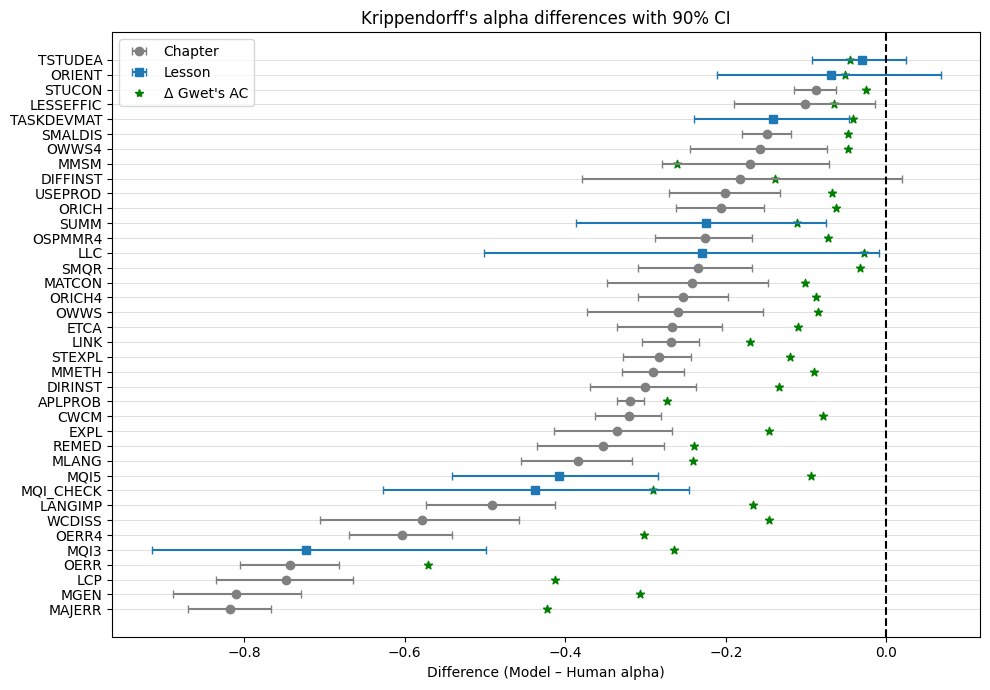

In [11]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

mask = diff_df["Variable"].isin(lesson_var)

# Segment level
ax.errorbar(
    diff_df.loc[~mask, "Difference"],
    y[~mask],
    xerr=[
        diff_df.loc[~mask, "Difference"] - diff_df.loc[~mask, "CI lower"],
        diff_df.loc[~mask, "CI upper"] - diff_df.loc[~mask, "Difference"],
    ],
    fmt="o",
    color="gray",
    capsize=3,
    label="Chapter"
)

# Lesson level
ax.errorbar(
    diff_df.loc[mask, "Difference"],
    y[mask],
    xerr=[
        diff_df.loc[mask, "Difference"] - diff_df.loc[mask, "CI lower"],
        diff_df.loc[mask, "CI upper"] - diff_df.loc[mask, "Difference"],
    ],
    fmt="s", 
    capsize=3,
    label="Lesson"
)

# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)

for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
summary_table_chapter = (
    diff_df.assign(Group=np.where(mask, "Lesson", "Chapter"))
    .groupby("Group")
    .agg(
        Mean_Difference=("Difference", "mean"),
        Mean_Delta_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count")
    )
    .round(4)
)

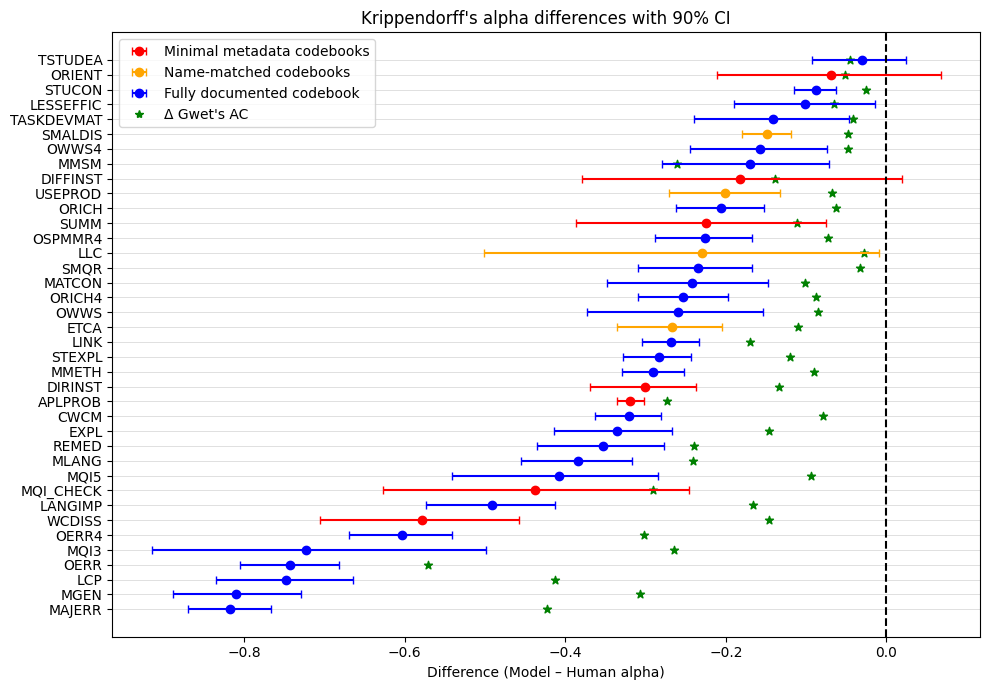

In [13]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

# Masks for each scale
mask1 = diff_df["Variable"].isin(no_codebook)
mask2 = diff_df["Variable"].isin(adapted_codebook)
mask3 = ~(mask1 | mask2)

# Define a style for each list
groups = [
    (mask1, "Minimal metadata codebooks", "red"),
    (mask2, "Name-matched codebooks", "orange"),
    (mask3, "Fully documented codebook", "blue"),
]

for mask, label, color in groups:
    ax.errorbar(
        diff_df.loc[mask, "Difference"],
        y[mask],
        xerr=[
            diff_df.loc[mask, "Difference"] - diff_df.loc[mask, "CI lower"],
            diff_df.loc[mask, "CI upper"] - diff_df.loc[mask, "Difference"],
        ],
        fmt='o',
        color=color,
        capsize=3,
        label=label,
    )
# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)
for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
group_col = np.select(
    [
        diff_df["Variable"].isin(no_codebook),
        diff_df["Variable"].isin(adapted_codebook)
    ],
    [
        "Minimal metadata codebooks",
        "Name-matched codebooks"
    ],
    default="Fully documented codebook"
)

order = [
    "Fully documented codebook",
    "Name-matched codebooks",
    "Minimal metadata codebooks"
]

summary_codebook = (
    diff_df.assign(Group=group_col)
    .assign(Group=lambda d: pd.Categorical(d["Group"], categories=order, ordered=True))
    .groupby("Group", observed=True)
    .agg(
        Mean_Difference=("Difference", "mean"),
        Mean_Delta_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count")
    )
    .round(4)
)

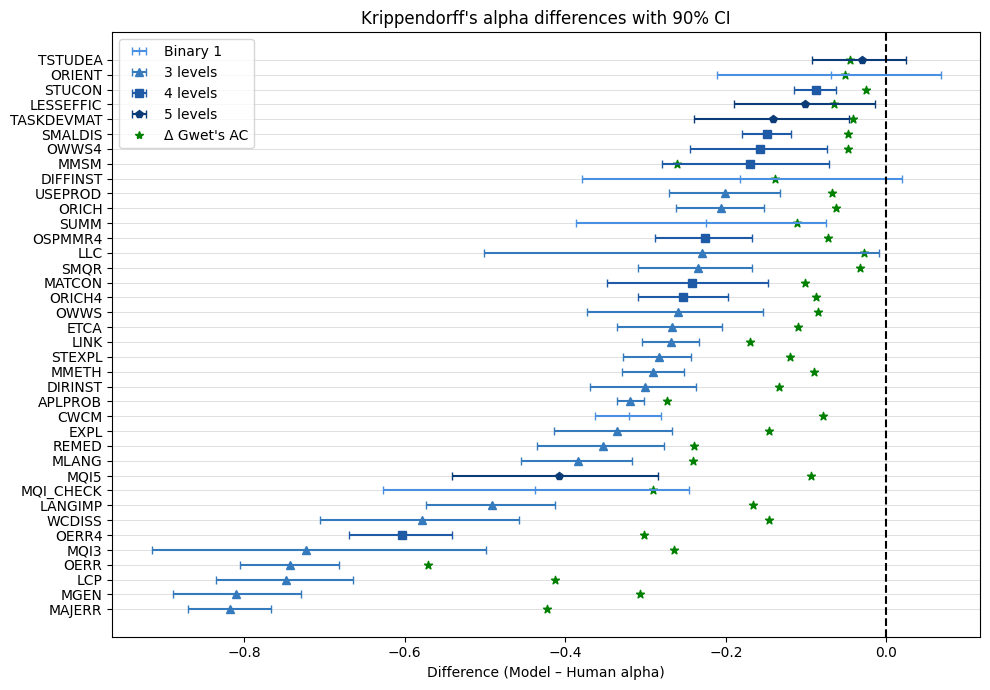

In [15]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

# Masks for each scale
mask1 = diff_df["Variable"].isin(scl_binary)
mask2 = diff_df["Variable"].isin(scl_three)
mask3 = diff_df["Variable"].isin(scl_four)
mask4 = diff_df["Variable"].isin(scl_five)

# A style for each list
groups = [
    (mask1, "Binary 1", "#4a90e2", '|'),
    (mask2, "3 levels", "#357abd", "^"),
    (mask3, "4 levels", "#1f5aa6", "s"),
    (mask4, "5 levels", "#0b3c78", "p"),
]

for mask, label, color, marker in groups:
    ax.errorbar(
        diff_df.loc[mask, "Difference"],
        y[mask],
        xerr=[
            diff_df.loc[mask, "Difference"] - diff_df.loc[mask, "CI lower"],
            diff_df.loc[mask, "CI upper"] - diff_df.loc[mask, "Difference"],
        ],
        fmt=marker,
        color=color,
        capsize=3,
        label=label,
    )
# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)
for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
scale_group = np.select(
    [
        diff_df["Variable"].isin(scl_binary),
        diff_df["Variable"].isin(scl_three),
        diff_df["Variable"].isin(scl_four),
        diff_df["Variable"].isin(scl_five),
    ],
    [
        "Binary",
        "3 levels",
        "4 levels",
        "5 levels",
    ],
)

order = ["Binary", "3 levels", "4 levels", "5 levels"]

summary_levels = (
    diff_df.assign(Scale=scale_group)
    .assign(Scale=lambda d: pd.Categorical(d["Scale"], categories=order))
    .groupby("Scale", observed=True)
    .agg(
        Mean_Difference=("Difference", "mean"),
        Mean_Delta_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count"),
    )
    .round(4)
)

In [17]:
big_summary = pd.concat([summary_table_chapter, summary_codebook, summary_levels], axis=0).reset_index(names="Grouping")
big_summary

,Grouping,Mean_Difference,Mean_Delta_AC,Mean_Human_alpha,N
0,Chapter,-0.3462,-0.1674,0.7928,30
1,Lesson,-0.2828,-0.1160,0.6675,8
2,Fully documented codebook,-0.3589,-0.1686,0.7709,27
3,Name-matched codebooks,-0.2115,-0.0632,0.7825,4
4,Minimal metadata codebooks,-0.3017,-0.1638,0.7400,7
5,Binary,-0.2469,-0.1347,0.7066,5
6,3 levels,-0.4212,-0.1947,0.7986,21
7,4 levels,-0.2359,-0.1181,0.7971,8
8,5 levels,-0.1702,-0.0612,0.6109,4


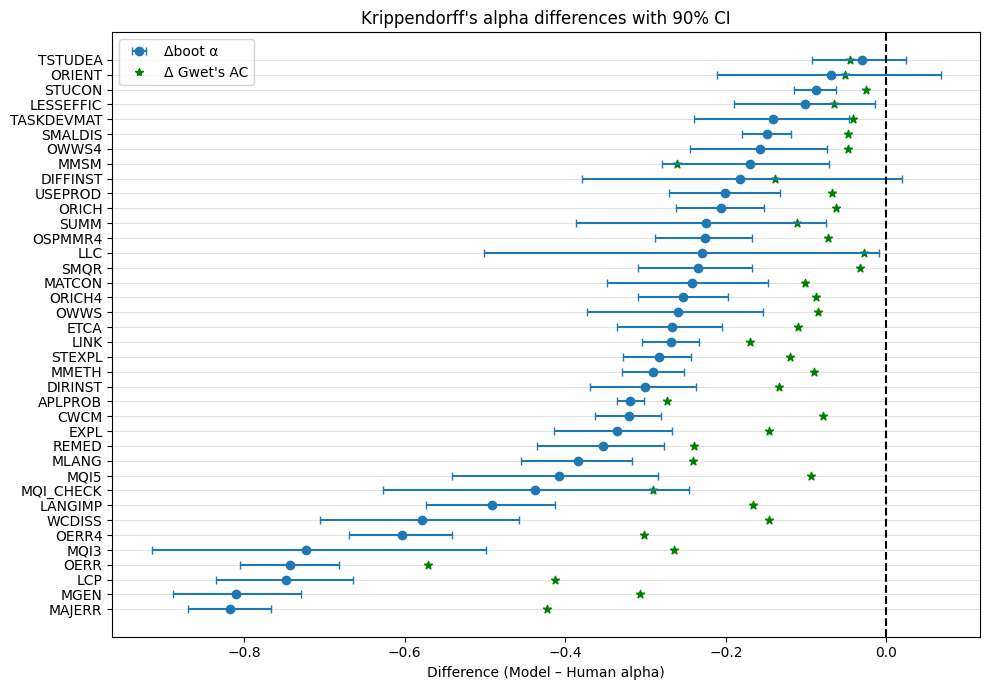

In [51]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(
    diff_df["Difference"],
    y,
    xerr=[diff_df["Difference"] - diff_df["CI lower"],
          diff_df["CI upper"] - diff_df["Difference"]],
    fmt="o",
    capsize=3,
    label="Δboot α"
)

# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)

for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
    
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

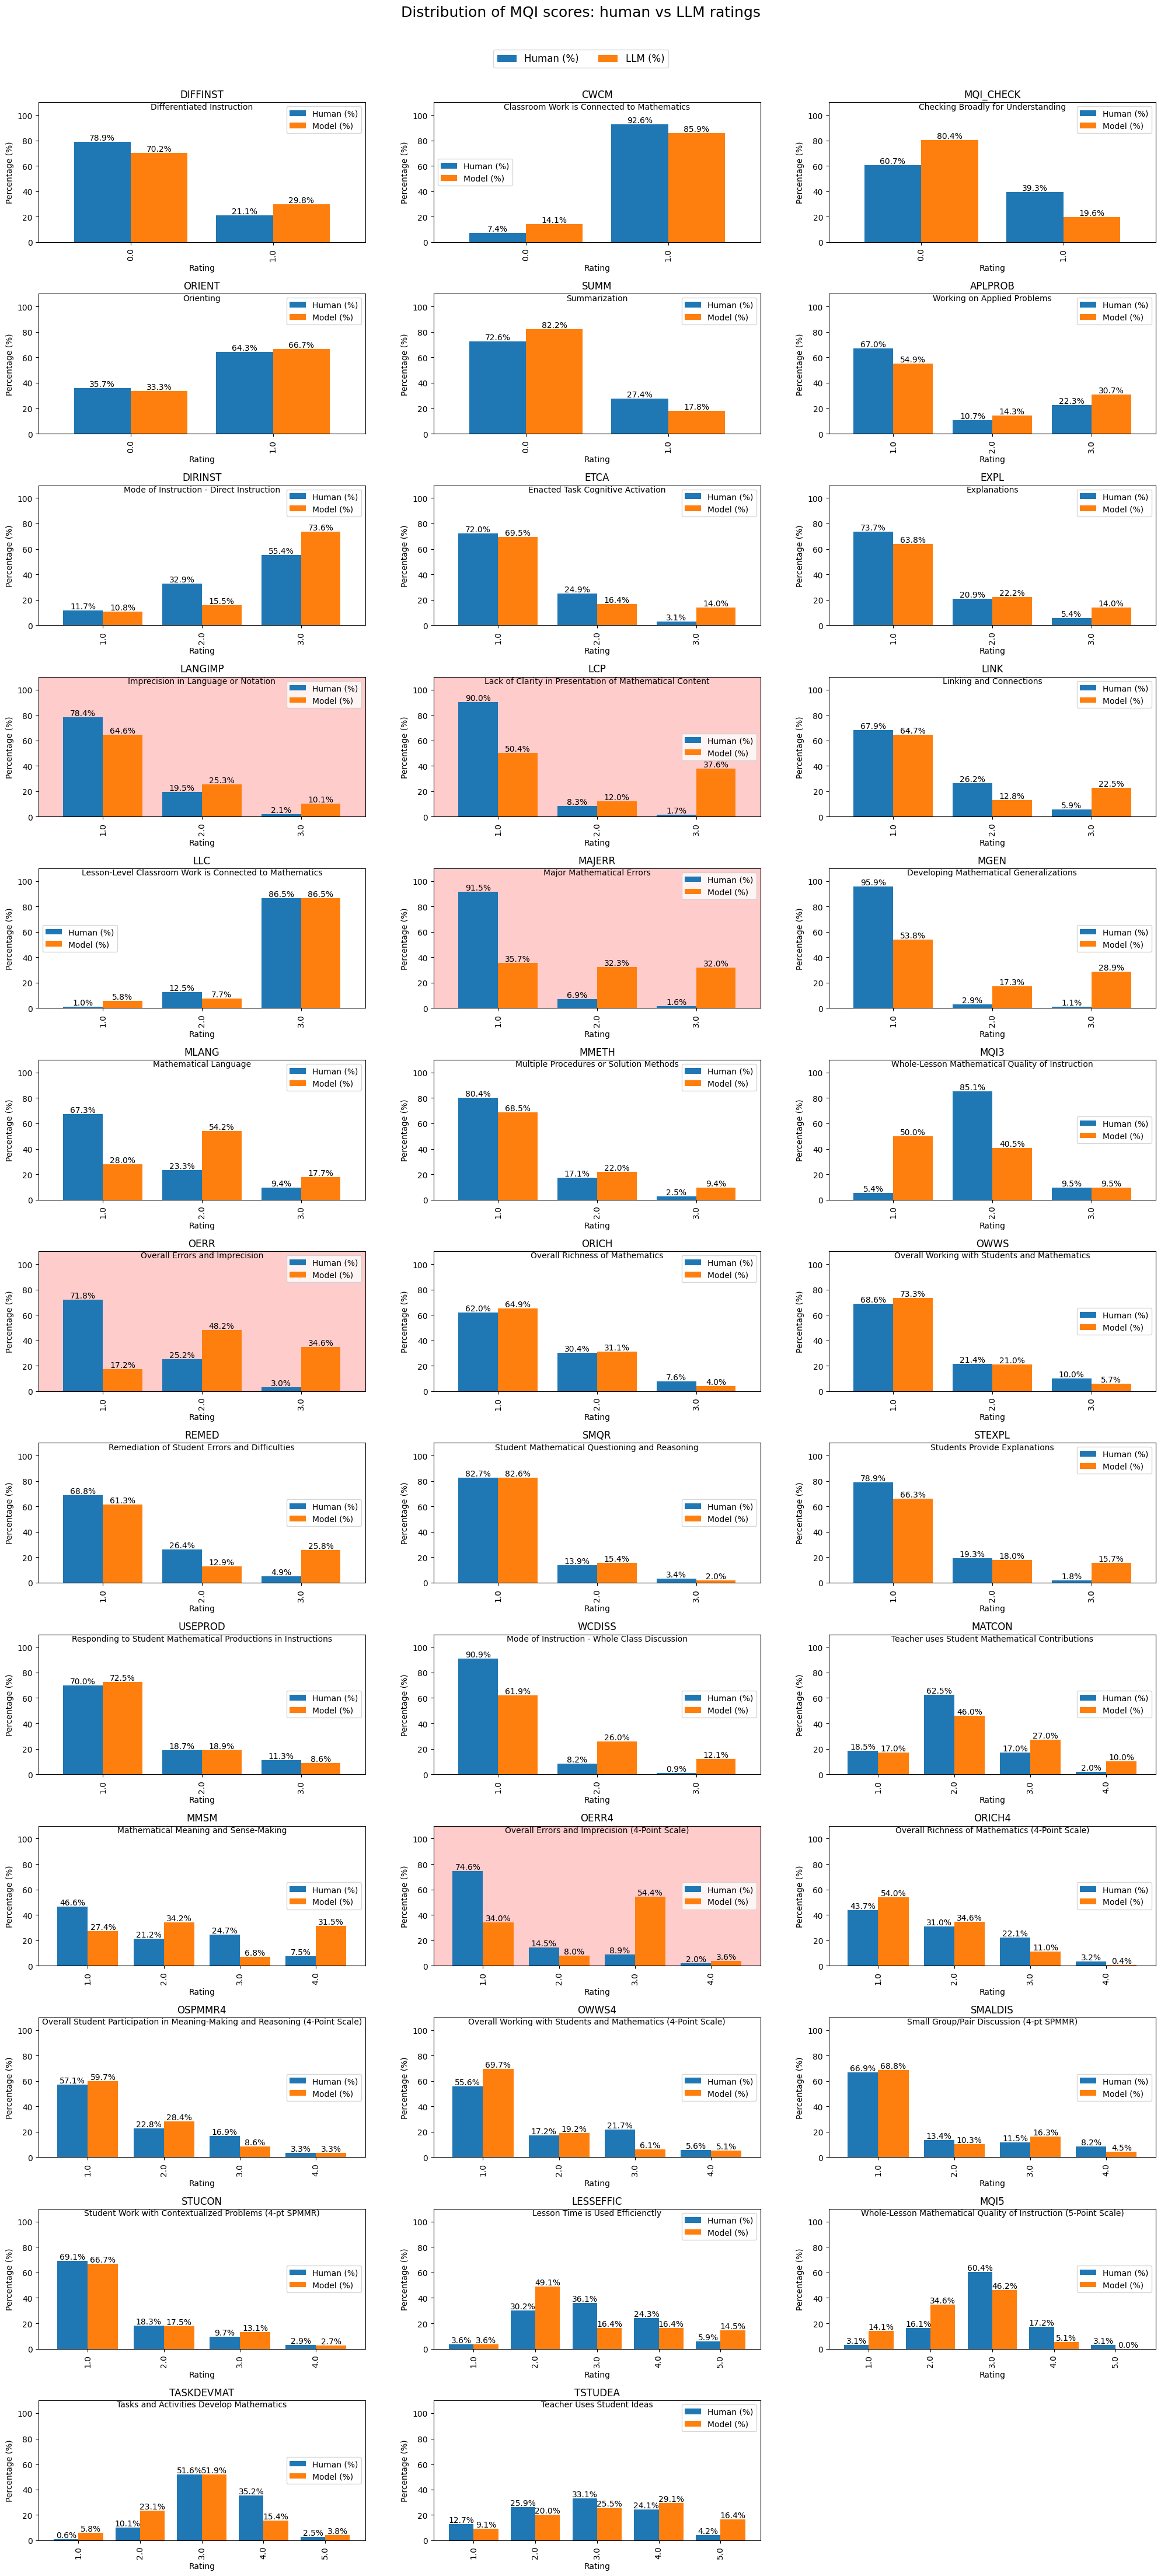

In [19]:
fig, axes = plt.subplots(ncols=3, nrows=13, figsize=(20, 45))
axes = axes.flatten()
all_vars = scl_binary + scl_three + scl_four + scl_five

for (var, ax) in zip(all_vars, axes):
    df = my_dico[var]["df"]
    rater_cols = [c for c in df.columns if c.startswith("Rater")]

    humans = df[rater_cols].stack().dropna()
    model = df["rating"]

    counts_h = humans.value_counts(normalize=True).sort_index() * 100
    counts_m = model.value_counts(normalize=True).sort_index() * 100

    idx = sorted(set(counts_h.index) | set(counts_m.index))
    plot_df = pd.DataFrame({
        "Human (%)": counts_h,
        "Model (%)": counts_m
    })

    plot_df.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(var)
    ax.text(0.5, 0.97, my_dico[var]["short_description"], ha="center", va="center", transform=ax.transAxes)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim([0, 110])
    if var in reversed_var:
        ax.set_facecolor("#ffcccc")

    # Display percent values
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=10)

fig.suptitle("Distribution of MQI scores: human vs LLM ratings", fontsize=18)
fig.legend(
    ["Human (%)", "LLM (%)"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2,
    fontsize=12
)

# Hide the useless axes
for ax in axes[len(all_vars):]:
    ax.set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("kripp_diff_barplots.png", dpi=300, bbox_inches="tight")
plt.show()

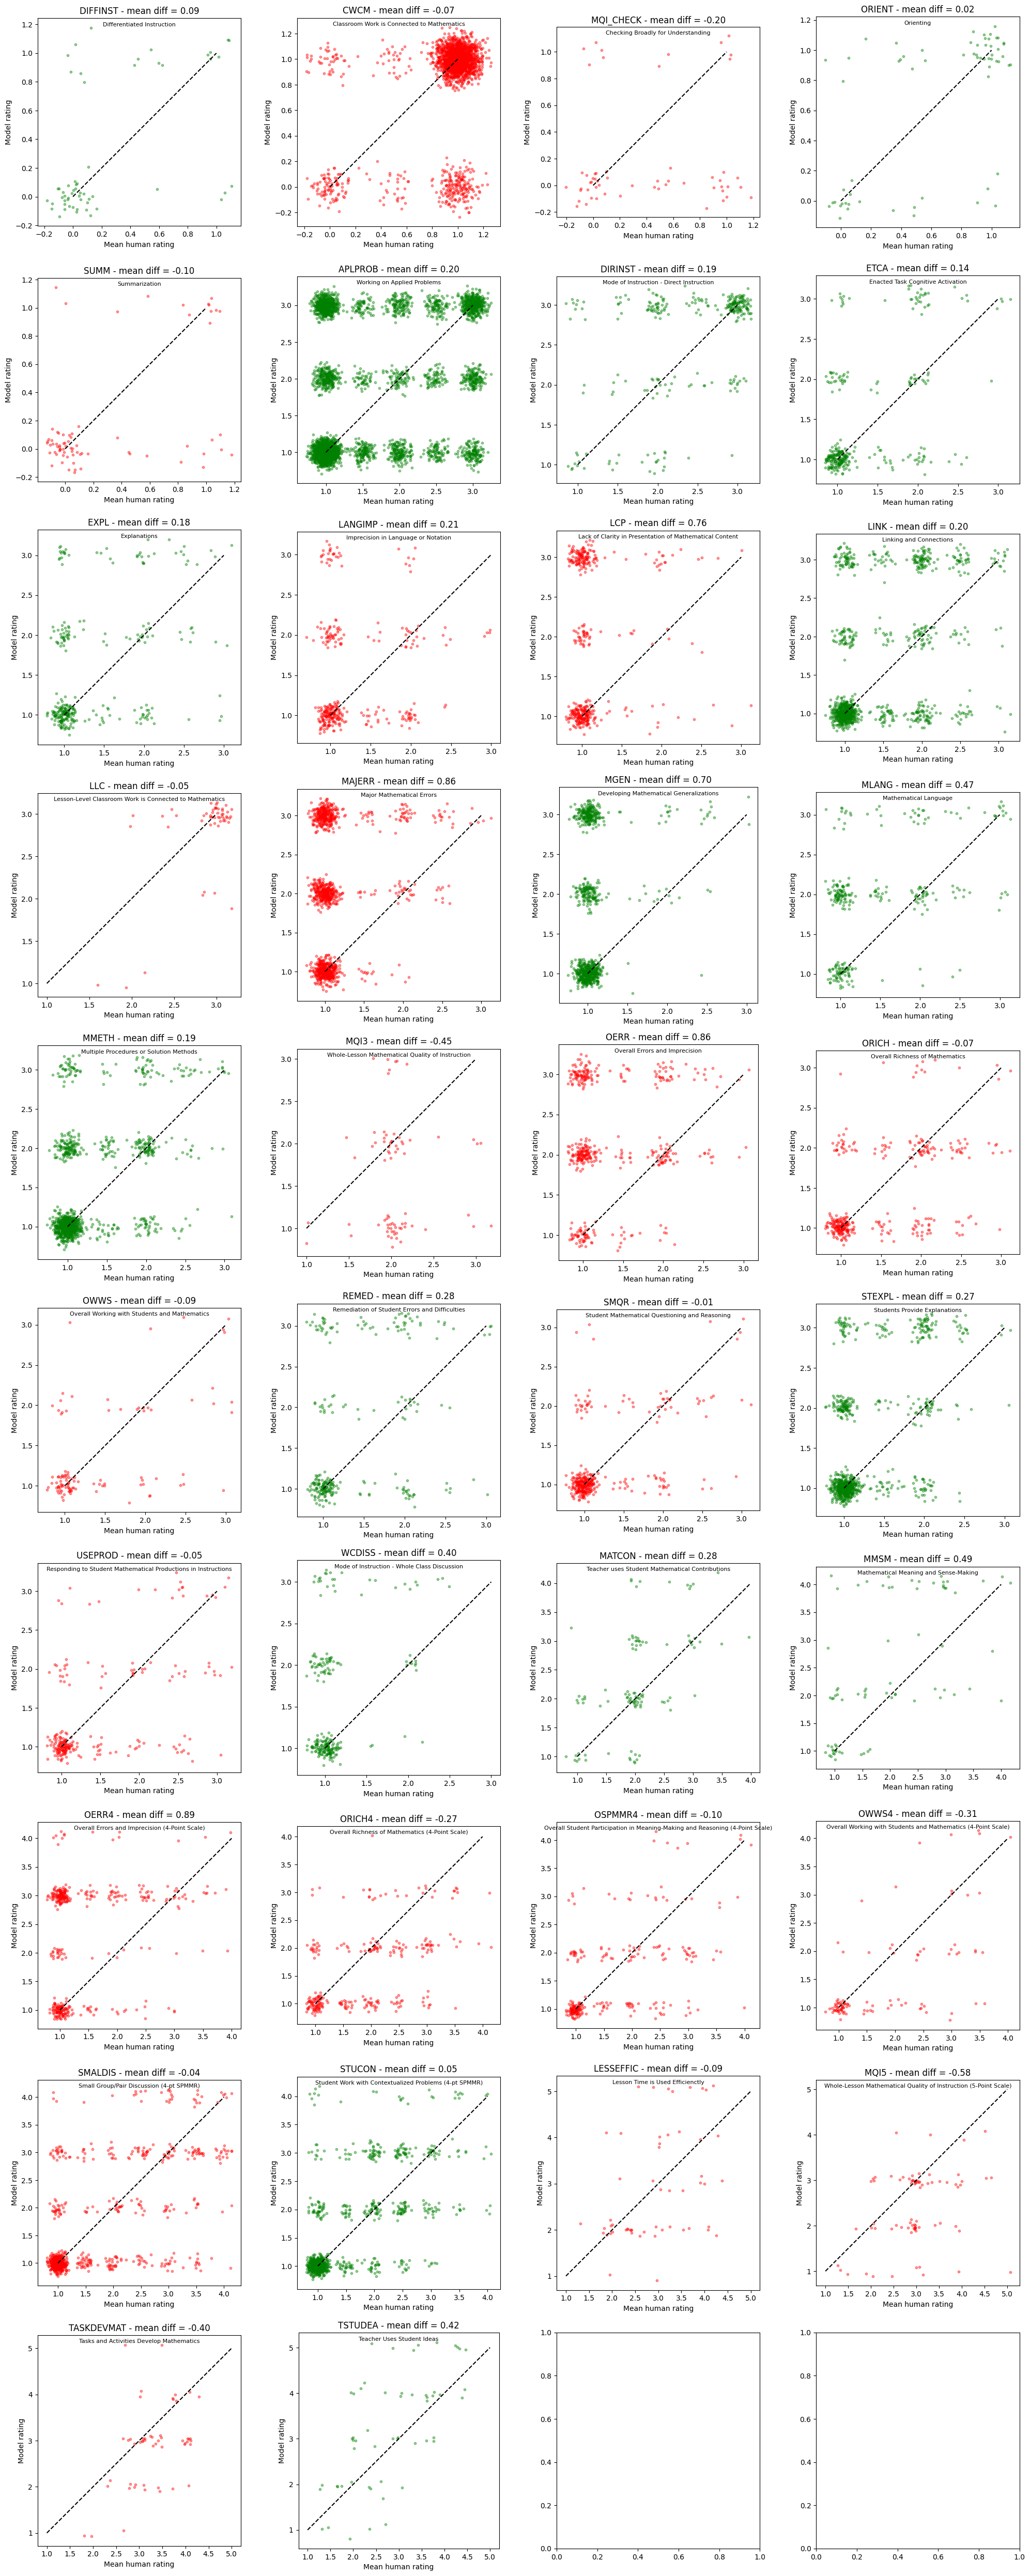

In [20]:
fig, axes = plt.subplots(ncols=4, nrows=10, figsize=(20, 50))
axes = axes.flatten()

for var, ax in zip(all_vars, axes):
    df = my_dico[var]["df"]
    rater_cols = [c for c in df.columns if c.startswith("Rater")]

    # Human mean per item
    human_mean = df[rater_cols].mean(axis=1, skipna=True)
    model = df["rating"]
    diff_mean = (model - human_mean).mean()
    if var not in reversed_var:
        colors = "green" if diff_mean > 0 else "red"
    else:
         colors = "red" if diff_mean > 0 else "green"

    # Jitter
    jitter_x = np.random.normal(0, 0.08, size=len(human_mean))
    jitter_y = np.random.normal(0, 0.08, size=len(model))

    # Scatter
    ax.scatter(
        human_mean + jitter_x,
        model + jitter_y,
        c=colors,
        alpha=0.4,
        s=10
    )

    # Diagonale y = x
    min_val = min(human_mean.min(), model.min())
    max_val = max(human_mean.max(), model.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color='black')

    ax.set_title(f"{var} - mean diff = {diff_mean:.2f}")
    ax.text(0.5, 0.97, my_dico[var]["short_description"], ha="center", va="center", transform=ax.transAxes, fontsize=8)
    ax.set_xlabel("Mean human rating")
    ax.set_ylabel("Model rating")
    ax.set_aspect("equal", "box")

plt.tight_layout()
plt.show()

# Comparison with 2.5-Flash-Lite

In [21]:
# To read the dict
with open("full_dictionnary_flash-lite_short-reasoning_examples.pkl", "rb") as f:
    my_dico_FL = pickle.load(f)

In [22]:
rows_kripp_FL = []

for var, info in my_dico_FL.items():
    results = info["kripp_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_kripp_FL.append({
        "Variable": var,
        "Human alpha": agg["alpha_human_panel_mean"],
        "Model alpha": agg["alpha_llm_substitution_panel_mean"],
        "Difference": agg["difference_mean"],
        "CI lower": agg["ci_lower_mean"],
        "CI upper": agg["ci_upper_mean"],
        "Non-inferior runs": agg["n_non_inferior"],
        "Total runs": agg["n_runs"],
    })

kripp_df_FL = pd.DataFrame(rows_kripp_FL)
kripp_df_FL

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs
0,APLPROB,0.800086,0.363969,-0.436117,-0.452345,-0.417725,0,1
1,CWCM,0.800122,0.490001,-0.310121,-0.350862,-0.268365,0,1
2,DIFFINST,0.686111,0.324489,-0.361622,-0.572845,-0.136105,0,1
3,DIRINST,0.806746,0.500039,-0.306707,-0.375298,-0.240150,0,1
4,ETCA,0.846368,0.538612,-0.307756,-0.381965,-0.240932,0,1
5,EXPL,0.802558,0.458493,-0.344065,-0.418129,-0.272876,0,1
6,LANGIMP,0.812107,0.337932,-0.474175,-0.551312,-0.399675,0,1
7,LCP,0.800509,-0.002554,-0.803063,-0.885298,-0.719097,0,1
8,LESSEFFIC,0.561268,0.549772,-0.011495,-0.084420,0.056038,0,1
9,LINK,0.801190,0.462763,-0.338427,-0.376188,-0.300577,0,1


In [23]:
rows_ac_FL = []

for var, info in my_dico_FL.items():
    results = info["gwet_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_ac_FL.append({
        "Variable": var,
        "Human AC": agg["ac_human_panel_mean"],
        "Model AC": agg["ac_llm_substitution_panel_mean"],
        "Delta AC": agg["difference_mean"],
    })

gwet_df_FL = pd.DataFrame(rows_ac_FL)
gwet_df_FL

,Variable,Human AC,Model AC,Delta AC
0,APLPROB,0.86334,0.415672,-0.447668
1,CWCM,0.96832,0.910128,-0.058192
2,DIFFINST,0.84232,0.716678,-0.125642
3,DIRINST,0.88634,0.720972,-0.165368
4,ETCA,0.96299,0.852461,-0.110529
5,EXPL,0.94063,0.731110,-0.209520
6,LANGIMP,0.96629,0.843283,-0.123007
7,LCP,0.98290,0.509970,-0.472930
8,LESSEFFIC,0.83413,0.842755,0.008625
9,LINK,0.92029,0.711347,-0.208943


In [24]:
metrics_df = (
    kripp_df
    .drop(columns=["Total runs"])
    .merge(gwet_df, on="Variable", how="left", validate="one_to_one")
)

metrics_df_FL = (
    kripp_df_FL
    .drop(columns=["Total runs"])
    .merge(gwet_df_FL, on="Variable", how="left", validate="one_to_one")
)

metrics_df["modele"] = "2.5-flash"
metrics_df_FL["modele"] = "2.5-flash-lite"

all_metrics_df = pd.concat([metrics_df, metrics_df_FL], ignore_index=True)
all_metrics_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Human AC,Model AC,Delta AC,modele
0,APLPROB,0.800086,0.480989,-0.319097,-0.335220,-0.302349,0,0.86334,0.589881,-0.273459,2.5-flash
1,CWCM,0.800122,0.479299,-0.320822,-0.363412,-0.280167,0,0.96832,0.889129,-0.079191,2.5-flash
2,DIFFINST,0.686111,0.503687,-0.182425,-0.379347,0.019057,0,0.84232,0.703282,-0.139038,2.5-flash
3,DIRINST,0.806746,0.505937,-0.300809,-0.369412,-0.237463,0,0.88634,0.753144,-0.133196,2.5-flash
4,ETCA,0.846368,0.579037,-0.267331,-0.335185,-0.205240,0,0.96299,0.853166,-0.109824,2.5-flash
...,...,...,...,...,...,...,...,...,...,...,...
71,SUMM,0.794811,0.482820,-0.311992,-0.476058,-0.159221,0,0.86351,0.642358,-0.221152,2.5-flash-lite
72,TASKDEVMAT,0.511010,0.359008,-0.152002,-0.244242,-0.063293,0,0.92980,0.909235,-0.020565,2.5-flash-lite
73,TSTUDEA,0.568654,0.534050,-0.034603,-0.092136,0.021523,0,0.78550,0.813202,0.027702,2.5-flash-lite
74,USEPROD,0.800141,0.592502,-0.207638,-0.285249,-0.138642,0,0.90167,0.815119,-0.086551,2.5-flash-lite


In [25]:
all_metrics_pivot = all_metrics_df.pivot(
    index="Variable",
    columns="modele",
    values=["Difference", "Delta AC", "CI lower", "CI upper"]
)
all_metrics_pivot.columns = [
    f"{metric}_{model}" for metric, model in all_metrics_pivot.columns
]
all_metrics_pivot["change_Alpha"] = all_metrics_pivot["Difference_2.5-flash"] - all_metrics_pivot["Difference_2.5-flash-lite"]
all_metrics_pivot["change_AC"] = all_metrics_pivot["Delta AC_2.5-flash"] - all_metrics_pivot["Delta AC_2.5-flash-lite"]


all_metrics_pivot

,Difference_2.5-flash,Difference_2.5-flash-lite,Delta AC_2.5-flash,Delta AC_2.5-flash-lite,CI lower_2.5-flash,CI lower_2.5-flash-lite,CI upper_2.5-flash,CI upper_2.5-flash-lite,change_Alpha,change_AC
Variable,,,,,,,,,,
APLPROB,-0.319097,-0.436117,-0.273459,-0.447668,-0.335220,-0.452345,-0.302349,-0.417725,0.117020,0.174209
CWCM,-0.320822,-0.310121,-0.079191,-0.058192,-0.363412,-0.350862,-0.280167,-0.268365,-0.010702,-0.020999
DIFFINST,-0.182425,-0.361622,-0.139038,-0.125642,-0.379347,-0.572845,0.019057,-0.136105,0.179197,-0.013397
DIRINST,-0.300809,-0.306707,-0.133196,-0.165368,-0.369412,-0.375298,-0.237463,-0.240150,0.005898,0.032172
ETCA,-0.267331,-0.307756,-0.109824,-0.110529,-0.335185,-0.381965,-0.205240,-0.240932,0.040425,0.000705
EXPL,-0.335855,-0.344065,-0.146038,-0.209520,-0.413432,-0.418129,-0.266647,-0.272876,0.008210,0.063482
LANGIMP,-0.491115,-0.474175,-0.166168,-0.123007,-0.573929,-0.551312,-0.413128,-0.399675,-0.016940,-0.043162
LCP,-0.748484,-0.803063,-0.412526,-0.472930,-0.835221,-0.885298,-0.664935,-0.719097,0.054580,0.060404
LESSEFFIC,-0.101329,-0.011495,-0.064646,0.008625,-0.189431,-0.084420,-0.014222,0.056038,-0.089834,-0.073271


In [26]:
print("Difference Krippendorff's alpha change from 2.5-flash-lite to 2.5-flash")
print("mean:", all_metrics_pivot["change_Alpha"].mean())
print("std:", all_metrics_pivot["change_Alpha"].std())
print("min:", all_metrics_pivot["change_Alpha"].min())
print("max:", all_metrics_pivot["change_Alpha"].max())
print()
print("Difference Gwet's AC2 change from 2.5-flash-lite to 2.5-flash")
print("mean:", all_metrics_pivot["change_AC"].mean())
print("std:", all_metrics_pivot["change_AC"].std())
print("min:", all_metrics_pivot["change_AC"].min())
print("max:", all_metrics_pivot["change_AC"].max())

Difference Krippendorff's alpha change from 2.5-flash-lite to 2.5-flash
mean: 0.051605032730635415
std: 0.10885510529325991
min: -0.21826264374782867
max: 0.35711361381006534

Difference Gwet's AC2 change from 2.5-flash-lite to 2.5-flash
mean: 0.007190123646936314
std: 0.1066461981548154
min: -0.3133480000000002
max: 0.2768783333333333


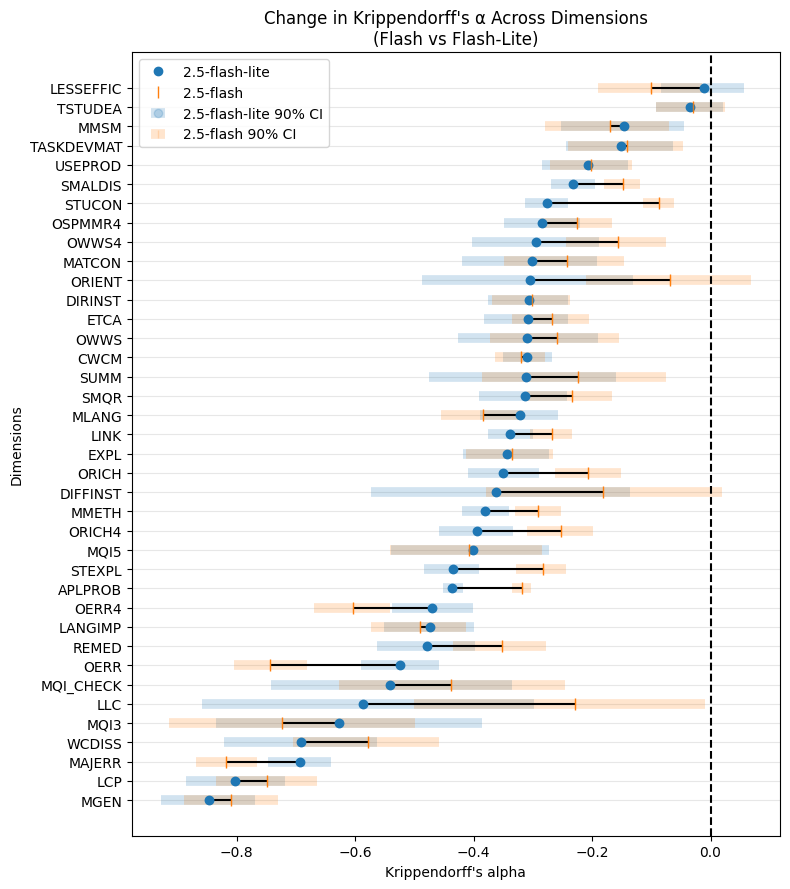

In [52]:
df = all_metrics_pivot.reset_index()
df_alpha = df.sort_values("Difference_2.5-flash-lite")

flash_lite = metrics_df_FL.sort_values("Difference")
flash = metrics_df.copy()
flash["flash-lite_diff"] = flash_lite["Difference"]
flash = flash.sort_values("flash-lite_diff")

y = flash_lite["Variable"].tolist()

fig, ax = plt.subplots(figsize=(8,9))


ax.errorbar(
    flash_lite["Difference"],
    y,
    xerr=[flash_lite["Difference"] - flash_lite["CI lower"],
          flash_lite["CI upper"] - flash_lite["Difference"]],
    fmt="o",
    alpha=0.2,
    label="2.5-flash-lite 90% CI",
    elinewidth=7
)
ax.errorbar(
    flash["Difference"],
    y,
    xerr=[flash["Difference"] - flash["CI lower"],
          flash["CI upper"] - flash["Difference"]],
    fmt="|",
    alpha=0.2,
    label="2.5-flash 90% CI",
    elinewidth=7
)
ax.hlines(
    y=y,
    xmin=df_alpha[["Difference_2.5-flash","Difference_2.5-flash-lite"]].min(axis=1),
    xmax=df_alpha[["Difference_2.5-flash","Difference_2.5-flash-lite"]].max(axis=1),
    color="black",
    alpha=1
)
ax.plot(df_alpha["Difference_2.5-flash-lite"], df_alpha["Variable"], "o", color="#1f77b4", label="2.5-flash-lite")
ax.plot(df_alpha["Difference_2.5-flash"], df_alpha["Variable"], "|", color="#ff7f0e", markersize=8, label="2.5-flash")

ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_title("Change in Krippendorff's α Across Dimensions\n(Flash vs Flash-Lite)")
ax.set_xlabel("Krippendorff's alpha")
ax.set_ylabel("Dimensions")

ax.grid(axis="y", linestyle="-", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

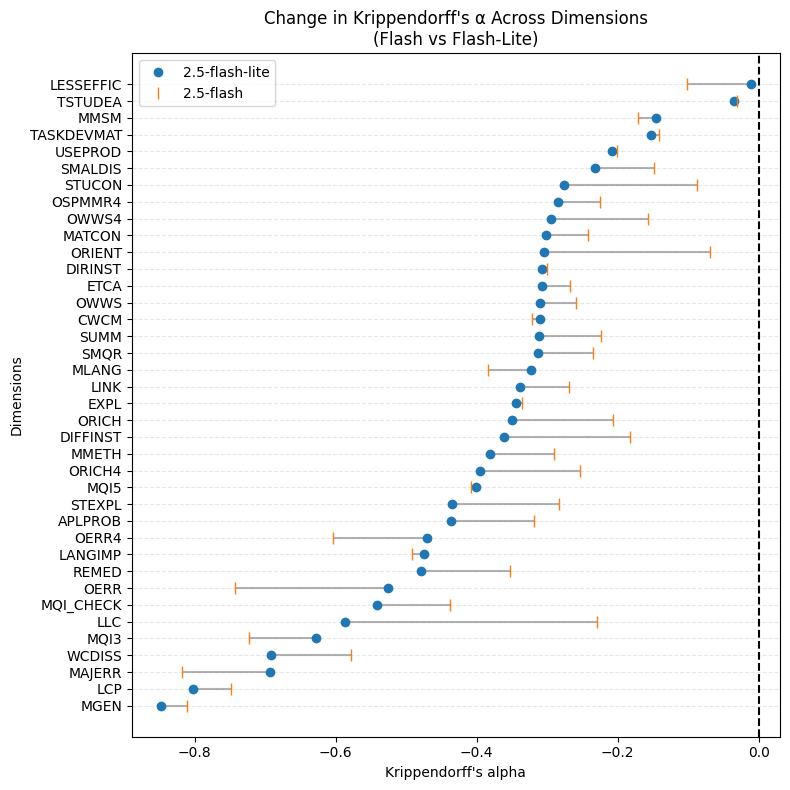

In [53]:
df = all_metrics_pivot.reset_index()
df_alpha = df.sort_values("Difference_2.5-flash-lite")

fig, ax = plt.subplots(figsize=(8,8))

ax.hlines(
    y=df_alpha["Variable"],
    xmin=df_alpha[["Difference_2.5-flash","Difference_2.5-flash-lite"]].min(axis=1),
    xmax=df_alpha[["Difference_2.5-flash","Difference_2.5-flash-lite"]].max(axis=1),
    color="grey",
    alpha=0.6
)

ax.plot(df_alpha["Difference_2.5-flash-lite"], df_alpha["Variable"], "o", label="2.5-flash-lite")
ax.plot(df_alpha["Difference_2.5-flash"], df_alpha["Variable"], "|", markersize=8, label="2.5-flash")

ax.axvline(0, color="black", linestyle="--")

ax.set_title("Change in Krippendorff's α Across Dimensions\n(Flash vs Flash-Lite)")
ax.set_xlabel("Krippendorff's alpha")
ax.set_ylabel("Dimensions")

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Paired t-test

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


def paired_ttest_pipeline(
    df: pd.DataFrame,
    col_a: str,
    col_b: str,
    alpha: float = 0.05,
    make_plot: bool = True,
    alternative: str = "two-sided",
):
    """
    Paired t-test pipeline with assumption checks.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the paired measurements.
    col_a : str
        First condition / model column.
    col_b : str
        Second condition / model column.
    alpha : float, default=0.05
        Significance level for assumption checks and tests.
    make_plot : bool, default=True
        Whether to draw diagnostic plots.
    alternative : str, default="two-sided"
        Alternative hypothesis for the paired t-test.
        One of: "two-sided", "greater", "less"

        IMPORTANT:
        The tested difference is (col_b - col_a).
        - "greater" tests whether col_b > col_a
        - "less" tests whether col_b < col_a

    Returns
    -------
    results : dict
        Dictionary containing descriptive statistics, assumption checks,
        paired t-test results, Wilcoxon backup test, and effect size.
    """

    # 1. Prepare paired data
    data = df[[col_a, col_b]].dropna().copy()
    if len(data) < 3:
        raise ValueError("Not enough paired observations after dropping missing values.")

    data["diff"] = data[col_b] - data[col_a]
    diff = data["diff"].to_numpy()
    n = len(diff)

    # 2. Descriptive statistics
    mean_a = data[col_a].mean()
    mean_b = data[col_b].mean()
    mean_diff = diff.mean()
    sd_diff = diff.std(ddof=1)
    median_diff = np.median(diff)

    # 3. Assumption checks for paired t-test
    #    Main assumption: approximate normality of the paired differences

    # 3a. Shapiro-Wilk test on paired differences
    shapiro_stat, shapiro_p = stats.shapiro(diff)

    # 3b. Outlier check on paired differences using z-scores
    if sd_diff > 0:
        z_scores = (diff - mean_diff) / sd_diff
        outlier_idx = np.where(np.abs(z_scores) > 3)[0]
    else:
        z_scores = np.zeros_like(diff)
        outlier_idx = np.array([], dtype=int)

    # 3c. Symmetry check for Wilcoxon suitability (descriptive only)
    # Wilcoxon signed-rank works best if differences are roughly symmetric.
    skewness = stats.skew(diff, bias=False) if n > 2 else np.nan

    # 4. Paired t-test
    t_res = stats.ttest_rel(
        data[col_b],
        data[col_a],
        alternative=alternative,
        nan_policy="omit"
    )
    t_stat = t_res.statistic
    t_p = t_res.pvalue

    # Confidence interval for the mean difference
    try:
        ci = t_res.confidence_interval(confidence_level=1 - alpha)
        ci_low, ci_high = ci.low, ci.high
    except Exception:
        # fallback manual CI
        se_diff = sd_diff / np.sqrt(n)
        dfree = n - 1
        if alternative == "two-sided":
            t_crit = stats.t.ppf(1 - alpha / 2, dfree)
            ci_low = mean_diff - t_crit * se_diff
            ci_high = mean_diff + t_crit * se_diff
        elif alternative == "greater":
            t_crit = stats.t.ppf(1 - alpha, dfree)
            ci_low = mean_diff - t_crit * se_diff
            ci_high = np.inf
        elif alternative == "less":
            t_crit = stats.t.ppf(1 - alpha, dfree)
            ci_low = -np.inf
            ci_high = mean_diff + t_crit * se_diff
        else:
            raise ValueError("alternative must be 'two-sided', 'greater', or 'less'.")

    # Effect size for paired t-test: Cohen's dz
    cohens_dz = mean_diff / sd_diff if sd_diff > 0 else np.nan

    # 5. Backup robust test: Wilcoxon signed-rank
    # Useful if normality is doubtful.
    try:
        wilcox_res = stats.wilcoxon(
            data[col_b],
            data[col_a],
            alternative=alternative,
            zero_method="wilcox"
        )
        wilcox_stat = wilcox_res.statistic
        wilcox_p = wilcox_res.pvalue
    except Exception:
        wilcox_stat = np.nan
        wilcox_p = np.nan

    # 6. Diagnostic plots
    if make_plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Histogram of paired differences
        axes[0].hist(diff, bins="auto", edgecolor="black")
        axes[0].axvline(mean_diff, linestyle="--")
        axes[0].set_title("Histogram of paired differences")
        axes[0].set_xlabel(f"{col_b} - {col_a}")
        axes[0].set_ylabel("Count")

        # QQ plot for normality
        stats.probplot(diff, dist="norm", plot=axes[1])
        axes[1].set_title("QQ plot of paired differences")

        plt.tight_layout()
        plt.show()

    # 7. Interpretation helpers
    normality_ok = shapiro_p >= alpha

    if normality_ok:
        recommendation = (
            "Normality of paired differences was not rejected. "
            "The paired t-test is acceptable."
        )
    else:
        recommendation = (
            "Normality of paired differences was rejected or looks doubtful. "
            "Interpret the paired t-test cautiously and rely on the Wilcoxon "
            "signed-rank test as a robustness check."
        )

    # 8. Print report
    print("=" * 70)
    print("PAIRED COMPARISON PIPELINE")
    print("=" * 70)
    print(f"Conditions compared: {col_a} vs {col_b}")
    print(f"Number of paired observations: n = {n}")
    print()
    print("Descriptive statistics")
    print(f"  Mean {col_a}: {mean_a:.4f}")
    print(f"  Mean {col_b}: {mean_b:.4f}")
    print(f"  Mean difference ({col_b} - {col_a}): {mean_diff:.4f}")
    print(f"  Median difference: {median_diff:.4f}")
    print(f"  SD of differences: {sd_diff:.4f}")
    print()
    print("Assumption checks")
    print(f"  Shapiro-Wilk normality test on paired differences: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
    print(f"  Skewness of paired differences: {skewness:.4f}")
    print(f"  Potential extreme outliers (|z| > 3): {len(outlier_idx)}")
    if len(outlier_idx) > 0:
        print(f"    Row indices among paired data: {outlier_idx.tolist()}")
    print()
    print("Paired t-test")
    print(f"  t = {t_stat:.4f}, p = {t_p:.4f}")
    print(f"  {100 * (1 - alpha):.1f}% CI of mean difference: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"  Cohen's dz = {cohens_dz:.4f}")
    print()
    print("Wilcoxon signed-rank test (robustness check)")
    print(f"  W = {wilcox_stat:.4f}, p = {wilcox_p:.4f}")
    print()
    print("Interpretation note")
    print(f"  {recommendation}")
    print("=" * 70)

    results = {
        "n": n,
        "mean_a": mean_a,
        "mean_b": mean_b,
        "mean_diff": mean_diff,
        "median_diff": median_diff,
        "sd_diff": sd_diff,
        "shapiro_W": shapiro_stat,
        "shapiro_p": shapiro_p,
        "skewness": skewness,
        "outlier_indices": outlier_idx.tolist(),
        "t_stat": t_stat,
        "t_p": t_p,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "cohens_dz": cohens_dz,
        "wilcoxon_W": wilcox_stat,
        "wilcoxon_p": wilcox_p,
        "normality_ok": normality_ok,
        "recommendation": recommendation,
        "paired_data": data.copy(),
    }

    return results

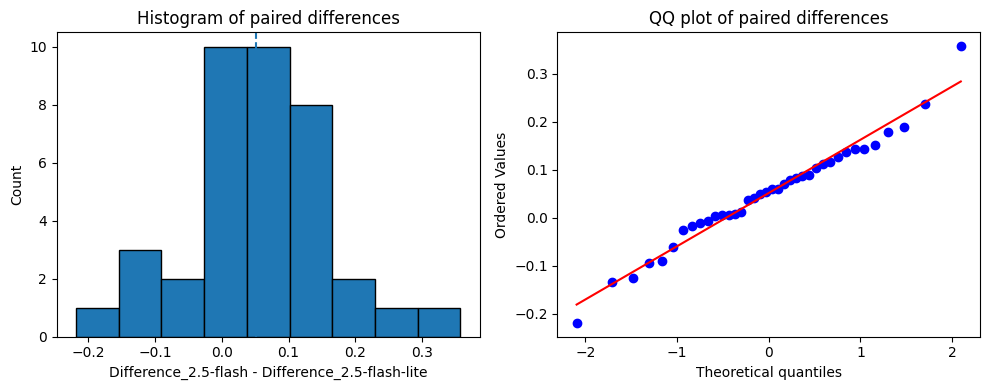

PAIRED COMPARISON PIPELINE
Conditions compared: Difference_2.5-flash-lite vs Difference_2.5-flash
Number of paired observations: n = 38

Descriptive statistics
  Mean Difference_2.5-flash-lite: -0.3844
  Mean Difference_2.5-flash: -0.3328
  Mean difference (Difference_2.5-flash - Difference_2.5-flash-lite): 0.0516
  Median difference: 0.0568
  SD of differences: 0.1089

Assumption checks
  Shapiro-Wilk normality test on paired differences: W = 0.9818, p = 0.7799
  Skewness of paired differences: 0.0739
  Potential extreme outliers (|z| > 3): 0

Paired t-test
  t = 2.9224, p = 0.0029
  95.0% CI of mean difference: [0.0218, inf]
  Cohen's dz = 0.4741

Wilcoxon signed-rank test (robustness check)
  W = 563.0000, p = 0.0022

Interpretation note
  Normality of paired differences was not rejected. The paired t-test is acceptable.


In [30]:
results = paired_ttest_pipeline(
    df=all_metrics_pivot,
    col_a="Difference_2.5-flash-lite",
    col_b="Difference_2.5-flash",
    alpha=0.05,
    make_plot=True,
    alternative="greater"
)

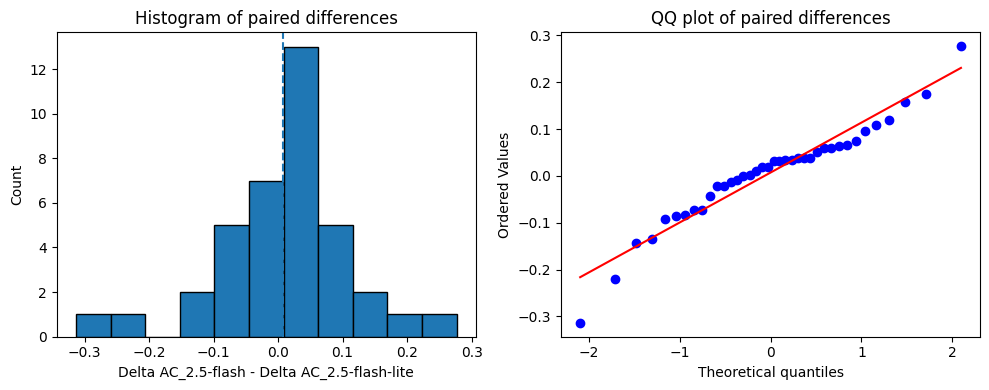

PAIRED COMPARISON PIPELINE
Conditions compared: Delta AC_2.5-flash-lite vs Delta AC_2.5-flash
Number of paired observations: n = 38

Descriptive statistics
  Mean Delta AC_2.5-flash-lite: -0.1638
  Mean Delta AC_2.5-flash: -0.1566
  Mean difference (Delta AC_2.5-flash - Delta AC_2.5-flash-lite): 0.0072
  Median difference: 0.0257
  SD of differences: 0.1066

Assumption checks
  Shapiro-Wilk normality test on paired differences: W = 0.9525, p = 0.1076
  Skewness of paired differences: -0.5379
  Potential extreme outliers (|z| > 3): 1
    Row indices among paired data: [20]

Paired t-test
  t = 0.4156, p = 0.3400
  95.0% CI of mean difference: [-0.0220, inf]
  Cohen's dz = 0.0674

Wilcoxon signed-rank test (robustness check)
  W = 432.0000, p = 0.1903

Interpretation note
  Normality of paired differences was not rejected. The paired t-test is acceptable.


In [31]:
results = paired_ttest_pipeline(
    df=all_metrics_pivot,
    col_a="Delta AC_2.5-flash-lite",
    col_b="Delta AC_2.5-flash",
    alpha=0.05,
    make_plot=True,
    alternative="greater"
)

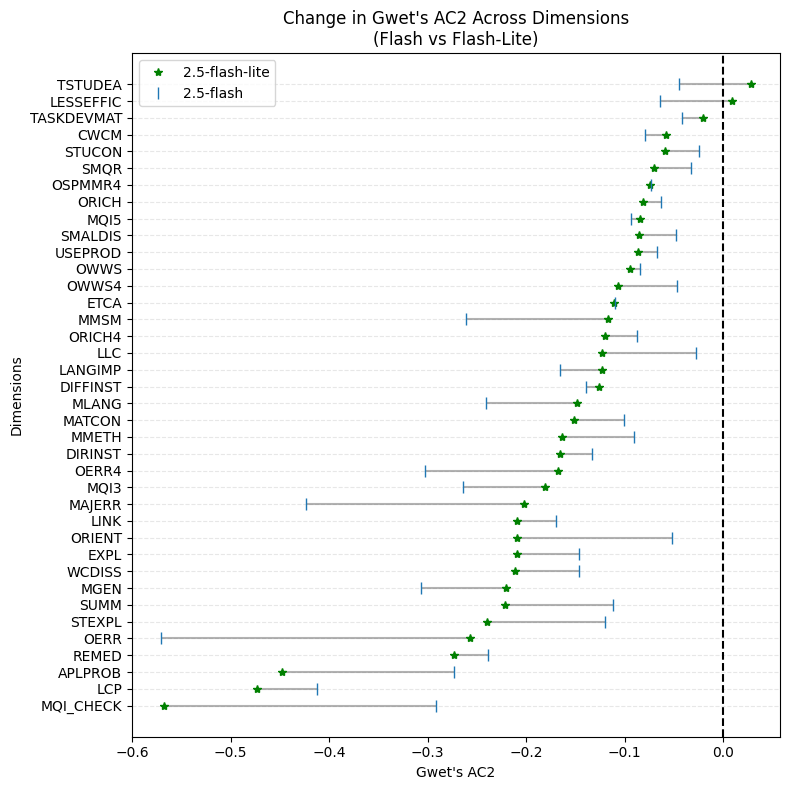

In [54]:
df_ac = df.sort_values("Delta AC_2.5-flash-lite")

fig, ax = plt.subplots(figsize=(8,8))

ax.hlines(
    y=df_ac["Variable"],
    xmin=df_ac[["Delta AC_2.5-flash","Delta AC_2.5-flash-lite"]].min(axis=1),
    xmax=df_ac[["Delta AC_2.5-flash","Delta AC_2.5-flash-lite"]].max(axis=1),
    color="grey",
    alpha=0.6
)

ax.plot(df_ac["Delta AC_2.5-flash-lite"], df_ac["Variable"], "*", color="green", label="2.5-flash-lite")
ax.plot(df_ac["Delta AC_2.5-flash"], df_ac["Variable"], "|", markersize=8, label="2.5-flash")

ax.axvline(0, color="black", linestyle="--")

ax.set_title("Change in Gwet's AC2 Across Dimensions\n(Flash vs Flash-Lite)")
ax.set_xlabel("Gwet's AC2")
ax.set_ylabel("Dimensions")

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

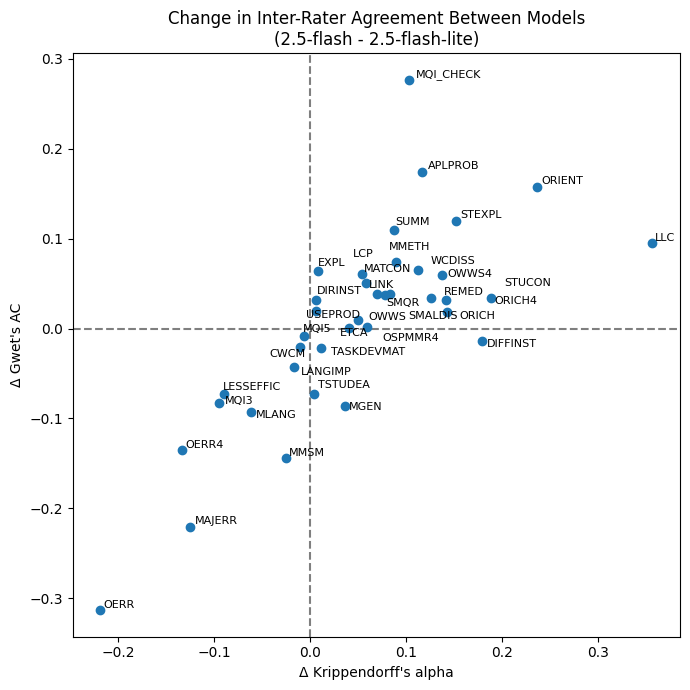

In [55]:
plot_df = all_metrics_pivot.reset_index().copy()

fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(plot_df["change_Alpha"], plot_df["change_AC"], zorder=1)

texts = []
for _, row in plot_df.iterrows():
    texts.append(
        ax.text(row["change_Alpha"], row["change_AC"], row["Variable"], fontsize=8)
    )
adjust_text(texts)

ax.axvline(0, linestyle="--", alpha=0.5, zorder=0, color="black")
ax.axhline(0, linestyle="--", alpha=0.5, zorder=0, color="black")

ax.set_xlabel("Δ Krippendorff's alpha")
ax.set_ylabel("Δ Gwet's AC")

ax.set_title("Change in Inter-Rater Agreement Between Models\n(2.5-flash - 2.5-flash-lite)")

plt.tight_layout()
plt.show()

In [34]:
mask = all_metrics_df["Variable"].isin(lesson_var)
summary_table_chapter = (
    all_metrics_df.assign(Group=np.where(mask, "Lesson", "Chapter"))
    .groupby(["Group", "modele"], observed=True)
    .agg(
        Mean_Diff_alpha=("Difference", "mean"),
        Mean_Diff_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count")
    )
    .round(4)
    .reset_index(level="modele")
)

In [35]:
group_col = np.select(
    [
        all_metrics_df["Variable"].isin(no_codebook),
        all_metrics_df["Variable"].isin(adapted_codebook)
    ],
    [
        "Minimal metadata codebooks",
        "Name-matched codebooks"
    ],
    default="Fully documented codebook"
)

order = [
    "Fully documented codebook",
    "Name-matched codebooks",
    "Minimal metadata codebooks"
]

summary_codebook = (
    all_metrics_df.assign(Group=group_col)
    .assign(Group=lambda d: pd.Categorical(d["Group"], categories=order))
    .groupby(["Group", "modele"], observed=True)
    .agg(
        Mean_Diff_alpha=("Difference", "mean"),
        Mean_Diff_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count")
    )
    .round(4)
    .reset_index(level="modele")
)

In [36]:
scale_group = np.select(
    [
        all_metrics_df["Variable"].isin(scl_binary),
        all_metrics_df["Variable"].isin(scl_three),
        all_metrics_df["Variable"].isin(scl_four),
        all_metrics_df["Variable"].isin(scl_five),
    ],
    [
        "Binary",
        "3 levels",
        "4 levels",
        "5 levels",
    ],
)
order = ["Binary", "3 levels", "4 levels", "5 levels"]
summary_levels = (
    all_metrics_df
    .assign(Scale=scale_group)
    .assign(Scale=lambda d: pd.Categorical(d["Scale"], categories=order))
    .groupby(["Scale", "modele"], observed=True)
    .agg(
        Mean_Diff_alpha=("Difference", "mean"),
        Mean_Diff_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count"),
    )
    .round(4)
    .reset_index(level="modele")
)

In [37]:
big_summary = pd.concat([summary_table_chapter, summary_codebook, summary_levels], axis=0).reset_index(names="Grouping")
big_summary

,Grouping,modele,Mean_Diff_alpha,Mean_Diff_AC,Mean_Human_alpha,N
0,Chapter,2.5-flash,-0.3462,-0.1674,0.7928,30
1,Chapter,2.5-flash-lite,-0.3882,-0.1615,0.7928,30
2,Lesson,2.5-flash,-0.2828,-0.1160,0.6675,8
3,Lesson,2.5-flash-lite,-0.3702,-0.1725,0.6675,8
4,Fully documented codebook,2.5-flash,-0.3589,-0.1686,0.7709,27
5,Fully documented codebook,2.5-flash-lite,-0.3822,-0.1433,0.7709,27
6,Name-matched codebooks,2.5-flash,-0.2115,-0.0632,0.7825,4
7,Name-matched codebooks,2.5-flash-lite,-0.3333,-0.1014,0.7825,4
8,Minimal metadata codebooks,2.5-flash,-0.3017,-0.1638,0.7400,7
9,Minimal metadata codebooks,2.5-flash-lite,-0.4220,-0.2784,0.7400,7


## Top 10 vs Bottom 10

In [38]:
all_metrics_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Human AC,Model AC,Delta AC,modele
0,APLPROB,0.800086,0.480989,-0.319097,-0.335220,-0.302349,0,0.86334,0.589881,-0.273459,2.5-flash
1,CWCM,0.800122,0.479299,-0.320822,-0.363412,-0.280167,0,0.96832,0.889129,-0.079191,2.5-flash
2,DIFFINST,0.686111,0.503687,-0.182425,-0.379347,0.019057,0,0.84232,0.703282,-0.139038,2.5-flash
3,DIRINST,0.806746,0.505937,-0.300809,-0.369412,-0.237463,0,0.88634,0.753144,-0.133196,2.5-flash
4,ETCA,0.846368,0.579037,-0.267331,-0.335185,-0.205240,0,0.96299,0.853166,-0.109824,2.5-flash
...,...,...,...,...,...,...,...,...,...,...,...
71,SUMM,0.794811,0.482820,-0.311992,-0.476058,-0.159221,0,0.86351,0.642358,-0.221152,2.5-flash-lite
72,TASKDEVMAT,0.511010,0.359008,-0.152002,-0.244242,-0.063293,0,0.92980,0.909235,-0.020565,2.5-flash-lite
73,TSTUDEA,0.568654,0.534050,-0.034603,-0.092136,0.021523,0,0.78550,0.813202,0.027702,2.5-flash-lite
74,USEPROD,0.800141,0.592502,-0.207638,-0.285249,-0.138642,0,0.90167,0.815119,-0.086551,2.5-flash-lite


In [39]:
top10_FL = all_metrics_df[all_metrics_df["modele"] == "2.5-flash-lite"].nlargest(10, "Difference")
bottom10_FL = all_metrics_df[all_metrics_df["modele"] == "2.5-flash-lite"].nsmallest(10, "Difference")

top10_F = all_metrics_df[all_metrics_df["modele"] == "2.5-flash"].nlargest(10, "Difference")
bottom10_F = all_metrics_df[all_metrics_df["modele"] == "2.5-flash"].nsmallest(10, "Difference")

In [40]:
set(top10_FL["Variable"]).intersection(top10_F["Variable"])

{'LESSEFFIC',
 'MMSM',
 'OWWS4',
 'SMALDIS',
 'STUCON',
 'TASKDEVMAT',
 'TSTUDEA',
 'USEPROD'}

In [41]:
set(top10_FL["Variable"]) - set(top10_F["Variable"])

{'MATCON', 'OSPMMR4'}

In [42]:
set(bottom10_FL["Variable"]).intersection(bottom10_F["Variable"])

{'LANGIMP', 'LCP', 'MAJERR', 'MGEN', 'MQI3', 'MQI_CHECK', 'OERR', 'WCDISS'}

In [43]:
set(bottom10_FL["Variable"]) - set(bottom10_F["Variable"])

{'LLC', 'REMED'}

In [44]:
top10_FL_AC = all_metrics_df[all_metrics_df["modele"] == "2.5-flash-lite"].nlargest(10, "Delta AC")
bottom10_FL_AC = all_metrics_df[all_metrics_df["modele"] == "2.5-flash-lite"].nsmallest(10, "Delta AC")

top10_F_AC = all_metrics_df[all_metrics_df["modele"] == "2.5-flash"].nlargest(10, "Delta AC")
bottom10_F_AC = all_metrics_df[all_metrics_df["modele"] == "2.5-flash"].nsmallest(10, "Delta AC")

In [45]:
set(top10_FL_AC["Variable"]).intersection(top10_F_AC["Variable"])

{'LESSEFFIC', 'ORICH', 'SMALDIS', 'SMQR', 'STUCON', 'TASKDEVMAT', 'TSTUDEA'}

In [46]:
set(top10_FL_AC["Variable"]) - set(top10_F_AC["Variable"])

{'CWCM', 'MQI5', 'OSPMMR4'}

In [47]:
set(bottom10_FL_AC["Variable"]).intersection(bottom10_F_AC["Variable"])

{'APLPROB', 'LCP', 'MGEN', 'MQI_CHECK', 'OERR'}

In [48]:
set(bottom10_FL_AC["Variable"]) - set(bottom10_F_AC["Variable"])

{'EXPL', 'REMED', 'STEXPL', 'SUMM', 'WCDISS'}

In [49]:
set(top10_FL["Variable"]).intersection(top10_FL_AC["Variable"])

{'LESSEFFIC', 'OSPMMR4', 'SMALDIS', 'STUCON', 'TASKDEVMAT', 'TSTUDEA'}

In [50]:
set(top10_FL["Variable"]) - set(top10_FL_AC["Variable"])

{'MATCON', 'MMSM', 'OWWS4', 'USEPROD'}